# Modelo 2: Bayesian Ridge Regression (modelo base/naive)
**Fase CRISP-DM:** Modeling  

## Descripción
Bayesian Ridge Regression es el modelo **base (naive)** del proyecto.  
Su función es establecer un **benchmark mínimo**: los modelos más complejos 
(SVR, XGBoost, LSTM, etc.) deben superar sus métricas para justificar su uso.

## Estrategia de ventana deslizante
Se transforma la serie temporal en un problema supervisado:  
cada muestra contiene las últimas **N horas** como features (X) para predecir la siguiente hora (y).  
- Ventana 48h  → se usan las 48 horas anteriores como predictores  
- Ventana 168h → se usan las 168 horas anteriores (1 semana)  

## Horizontes de predicción
- **1h** → benchmark  
- **24h** → predicción iterativa (el modelo predice paso a paso)  
- **168h** → predicción iterativa (1 semana)  

## Métricas
- **RMSE** (Root Mean Squared Error) en veh/h  
- **R²** (coeficiente de determinación)

## Paso 1: Carga de datos y configuración del entorno

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Carga de los tres splits cronológicos
# ---------------------------------------------------------------------------
train_df = pd.read_csv('../../data/processed/Split_Datasets/data_train.csv')
val_df   = pd.read_csv('../../data/processed/Split_Datasets/data_val.csv')
test_df  = pd.read_csv('../../data/processed/Split_Datasets/data_test.csv')

def preparar_indice_temporal(df):
    """Convierte 'fecha' en índice datetime con frecuencia horaria estricta."""
    df['fecha'] = pd.to_datetime(df['fecha'])
    df.set_index('fecha', inplace=True)
    df.sort_index(inplace=True)
    df = df.asfreq('h')
    return df

train_df = preparar_indice_temporal(train_df)
val_df   = preparar_indice_temporal(val_df)
test_df  = preparar_indice_temporal(test_df)

# ---------------------------------------------------------------------------
# Definición de columnas
# ---------------------------------------------------------------------------
cols_endogenas  = [col for col in train_df.columns
                   if 'intensidad' in col or 'ocupacion' in col or 'vmed' in col]
cols_exogenas   = ['hora', 'dia_semana', 'mes', 'es_finde']
cols_intensidad = [col for col in cols_endogenas if 'intensidad' in col]

print("--- ESTRUCTURA DE DATOS ---")
print(f"Train : {train_df.shape} | {train_df.index.min()} → {train_df.index.max()}")
print(f"Val   : {val_df.shape}   | {val_df.index.min()} → {val_df.index.max()}")
print(f"Test  : {test_df.shape}  | {test_df.index.min()} → {test_df.index.max()}")
print(f"\nColumnas objetivo (intensidad): {cols_intensidad}")

--- ESTRUCTURA DE DATOS ---
Train : (16080, 16) | 2024-01-01 00:00:00 → 2025-10-31 23:00:00
Val   : (1464, 16)   | 2025-11-01 00:00:00 → 2025-12-31 23:00:00
Test  : (1416, 16)  | 2026-01-01 00:00:00 → 2026-02-28 23:00:00

Columnas objetivo (intensidad): ['intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782']


## Paso 1.1: Imputación de valores nulos

In [5]:
def limpiar_nulos(df, cols_endo):
    """Imputa nulos por interpolación lineal y reconstruye variables de calendario."""
    df[cols_endo] = df[cols_endo].interpolate(method='linear', limit_direction='both')
    df['hora']       = df.index.hour
    df['dia_semana'] = df.index.dayofweek
    df['mes']        = df.index.month
    df['es_finde']   = (df['dia_semana'] >= 5).astype(int)
    return df

train_df = limpiar_nulos(train_df, cols_endogenas)
val_df   = limpiar_nulos(val_df,   cols_endogenas)
test_df  = limpiar_nulos(test_df,  cols_endogenas)

nulos_total = (train_df.isnull().sum().sum() +
               val_df.isnull().sum().sum()   +
               test_df.isnull().sum().sum())
print(f"✅ Nulos totales tras imputación: {nulos_total}")

✅ Nulos totales tras imputación: 0


## Paso 2: Construcción del dataset supervisado (ventana deslizante)
Se convierte la serie temporal en matrices X (features) e y (target) para scikit-learn.

In [6]:
def crear_dataset_supervisado(df, cols_target, cols_exog, window_size):
    """
    Transforma la serie temporal en un problema de regresión supervisada.
    
    Para cada instante t:
      X = [valores de cols_target en t-window_size … t-1] + [variables exógenas en t]
      y = [valores de cols_target en t]

    Parámetros
    ----------
    df          : DataFrame con índice temporal
    cols_target : columnas a predecir (y)
    cols_exog   : variables de calendario (exógenas)
    window_size : número de horas de historia que se usan como features

    Retorna
    -------
    X : np.ndarray de forma (n_muestras, window_size * n_targets + n_exog)
    y : np.ndarray de forma (n_muestras, n_targets)
    """
    X_list, y_list = [], []

    # Valores numéricos de las columnas objetivo y exógenas
    datos_target = df[cols_target].values
    datos_exog   = df[cols_exog].values

    for i in range(window_size, len(df)):
        # Ventana de historia: aplanada en una sola fila
        ventana   = datos_target[i - window_size : i].flatten()
        # Variables de calendario del instante actual
        contexto  = datos_exog[i]
        X_list.append(np.concatenate([ventana, contexto]))
        y_list.append(datos_target[i])

    return np.array(X_list), np.array(y_list)

# ---------------------------------------------------------------------------
# Ventana de 48 horas (benchmark principal)
# ---------------------------------------------------------------------------
WINDOW_SIZE = 48

print(f"Construyendo datasets supervisados con ventana de {WINDOW_SIZE} horas...")

X_train, y_train = crear_dataset_supervisado(train_df, cols_intensidad, cols_exogenas, WINDOW_SIZE)
X_val,   y_val   = crear_dataset_supervisado(val_df,   cols_intensidad, cols_exogenas, WINDOW_SIZE)
X_test,  y_test  = crear_dataset_supervisado(test_df,  cols_intensidad, cols_exogenas, WINDOW_SIZE)

print(f"✅ X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"✅ X_val  : {X_val.shape}   | y_val  : {y_val.shape}")
print(f"✅ X_test : {X_test.shape}  | y_test : {y_test.shape}")

Construyendo datasets supervisados con ventana de 48 horas...
✅ X_train: (16032, 196) | y_train: (16032, 4)
✅ X_val  : (1416, 196)   | y_val  : (1416, 4)
✅ X_test : (1368, 196)  | y_test : (1368, 4)


## Paso 3: Entrenamiento del modelo Bayesian Ridge
No necesita normalización obligatoria (es un modelo lineal bayesiano con regularización automática),
pero se aplica StandardScaler para estabilidad numérica.

In [7]:
from sklearn.linear_model import BayesianRidge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ---------------------------------------------------------------------------
# Pipeline: normalización + Bayesian Ridge
# ---------------------------------------------------------------------------
# MultiOutputRegressor permite predecir los 4 sensores a la vez
modelo_bayesian = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', MultiOutputRegressor(
        BayesianRidge(
            max_iter=300,
            tol=1e-3
        )
    ))
])

print("⏳ Entrenando Bayesian Ridge Regression...")
modelo_bayesian.fit(X_train, y_train)
print("✅ Modelo entrenado correctamente.")
print(f"   Features de entrada : {X_train.shape[1]}")
print(f"   Variables objetivo  : {y_train.shape[1]} ({cols_intensidad})")

⏳ Entrenando Bayesian Ridge Regression...
✅ Modelo entrenado correctamente.
   Features de entrada : 196
   Variables objetivo  : 4 (['intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782'])


## Paso 4: Predicción multi-horizonte
Para horizontes > 1h se usa **predicción iterativa**:  
la predicción de t+1 se añade a la ventana para predecir t+2, y así sucesivamente.

In [8]:
def predecir_iterativo(modelo, ultimo_train, df_futuro, cols_target, cols_exog, window_size, steps):
    """
    Predicción iterativa (autoregresiva) para horizonte > 1 paso.
    
    Parámetros
    ----------
    modelo       : modelo entrenado (Pipeline sklearn)
    ultimo_train : últimas 'window_size' filas del train (valores reales como arranque)
    df_futuro    : DataFrame de val o test (para las variables exógenas futuras)
    steps        : número de pasos a predecir
    
    Retorna
    -------
    np.ndarray de forma (steps, n_targets)
    """
    # Buffer con la historia más reciente (valores reales al inicio)
    buffer = ultimo_train[cols_target].values[-window_size:].copy()
    predicciones = []

    for i in range(steps):
        # Construir el vector de features para el paso i
        exog_i    = df_futuro[cols_exog].iloc[i].values
        x_i       = np.concatenate([buffer.flatten(), exog_i]).reshape(1, -1)

        # Predicción de un paso
        pred_i    = modelo.predict(x_i)[0]  # shape (n_targets,)
        predicciones.append(pred_i)

        # Actualizar el buffer: desplazar la ventana e insertar la predicción
        buffer = np.vstack([buffer[1:], pred_i])

    return np.array(predicciones)

# ---------------------------------------------------------------------------
# Generación de predicciones sobre validación
# ---------------------------------------------------------------------------
ultimo_train = train_df.iloc[-WINDOW_SIZE:]

print("--- GENERANDO PREDICCIONES SOBRE VALIDACIÓN ---")

pred_1h   = predecir_iterativo(modelo_bayesian, ultimo_train, val_df,
                                cols_intensidad, cols_exogenas, WINDOW_SIZE, steps=1)
print("✅ Predicción a  1 hora  completada.")

pred_24h  = predecir_iterativo(modelo_bayesian, ultimo_train, val_df,
                                cols_intensidad, cols_exogenas, WINDOW_SIZE, steps=24)
print("✅ Predicción a 24 horas completada.")

pred_168h = predecir_iterativo(modelo_bayesian, ultimo_train, val_df,
                                cols_intensidad, cols_exogenas, WINDOW_SIZE, steps=168)
print("✅ Predicción a 168 horas (1 semana) completada.")

# Convertir a DataFrames con índice temporal
idx_val = val_df.index
df_pred_1h   = pd.DataFrame(pred_1h,   index=idx_val[:1],   columns=cols_intensidad)
df_pred_24h  = pd.DataFrame(pred_24h,  index=idx_val[:24],  columns=cols_intensidad)
df_pred_168h = pd.DataFrame(pred_168h, index=idx_val[:168], columns=cols_intensidad)

--- GENERANDO PREDICCIONES SOBRE VALIDACIÓN ---
✅ Predicción a  1 hora  completada.
✅ Predicción a 24 horas completada.
✅ Predicción a 168 horas (1 semana) completada.


## Paso 5: Evaluación de métricas (RMSE y R²)

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluar_predicciones(df_real, df_pred, cols_obj, etiqueta):
    """Calcula RMSE y R² para cada sensor y el promedio global."""
    print(f"\n[ HORIZONTE: {etiqueta} ]")
    rmse_vals, r2_vals = [], []
    for col in cols_obj:
        n    = len(df_pred)
        real = df_real[col].iloc[:n].values
        pred = df_pred[col].values
        mask = ~np.isnan(real) & ~np.isnan(pred)
        rmse = np.sqrt(mean_squared_error(real[mask], pred[mask]))
        r2   = r2_score(real[mask], pred[mask])
        rmse_vals.append(rmse)
        r2_vals.append(r2)
        print(f"  Sensor {col[-4:]}  →  RMSE: {rmse:>8.2f} veh/h  |  R²: {r2:>7.4f}")
    print(f"  {'─'*52}")
    print(f"  PROMEDIO GLOBAL   →  RMSE: {np.mean(rmse_vals):>8.2f} veh/h  |  R²: {np.mean(r2_vals):>7.4f}")
    return np.mean(rmse_vals), np.mean(r2_vals)

print("========================================")
print("   RESULTADOS BAYESIAN RIDGE — VALIDACIÓN")
print("========================================")
rmse_1h,   r2_1h   = evaluar_predicciones(val_df, df_pred_1h,   cols_intensidad, " 1 HORA   (benchmark)")
rmse_24h,  r2_24h  = evaluar_predicciones(val_df, df_pred_24h,  cols_intensidad, "24 HORAS  (medio plazo)")
rmse_168h, r2_168h = evaluar_predicciones(val_df, df_pred_168h, cols_intensidad, "168 HORAS (largo plazo)")

print("\n--- TABLA RESUMEN BAYESIAN RIDGE ---")
resumen = pd.DataFrame({
    'Horizonte'   : ['1h', '24h', '168h'],
    'RMSE (veh/h)': [rmse_1h, rmse_24h, rmse_168h],
    'R²'          : [r2_1h, r2_24h, r2_168h]
})
print(resumen.to_string(index=False))

   RESULTADOS BAYESIAN RIDGE — VALIDACIÓN

[ HORIZONTE:  1 HORA   (benchmark) ]
  Sensor 3820  →  RMSE:    89.80 veh/h  |  R²:     nan
  Sensor 6642  →  RMSE:   219.53 veh/h  |  R²:     nan
  Sensor 6676  →  RMSE:    95.35 veh/h  |  R²:     nan
  Sensor 6782  →  RMSE:   574.19 veh/h  |  R²:     nan
  ────────────────────────────────────────────────────
  PROMEDIO GLOBAL   →  RMSE:   244.72 veh/h  |  R²:     nan

[ HORIZONTE: 24 HORAS  (medio plazo) ]
  Sensor 3820  →  RMSE:  1407.71 veh/h  |  R²: -0.2141
  Sensor 6642  →  RMSE:  2544.15 veh/h  |  R²: -4.4050
  Sensor 6676  →  RMSE:  1325.47 veh/h  |  R²:  0.4760
  Sensor 6782  →  RMSE:   679.04 veh/h  |  R²:  0.6649
  ────────────────────────────────────────────────────
  PROMEDIO GLOBAL   →  RMSE:  1489.09 veh/h  |  R²: -0.8695

[ HORIZONTE: 168 HORAS (largo plazo) ]
  Sensor 3820  →  RMSE:  1103.47 veh/h  |  R²:  0.6563
  Sensor 6642  →  RMSE:  2363.45 veh/h  |  R²: -0.5736
  Sensor 6676  →  RMSE:  1215.57 veh/h  |  R²:  0.6449
  Sen

## Paso 6: Visualización de resultados

✅ Gráfico guardado: 'grafico_bayesian_ridge_168h.png'


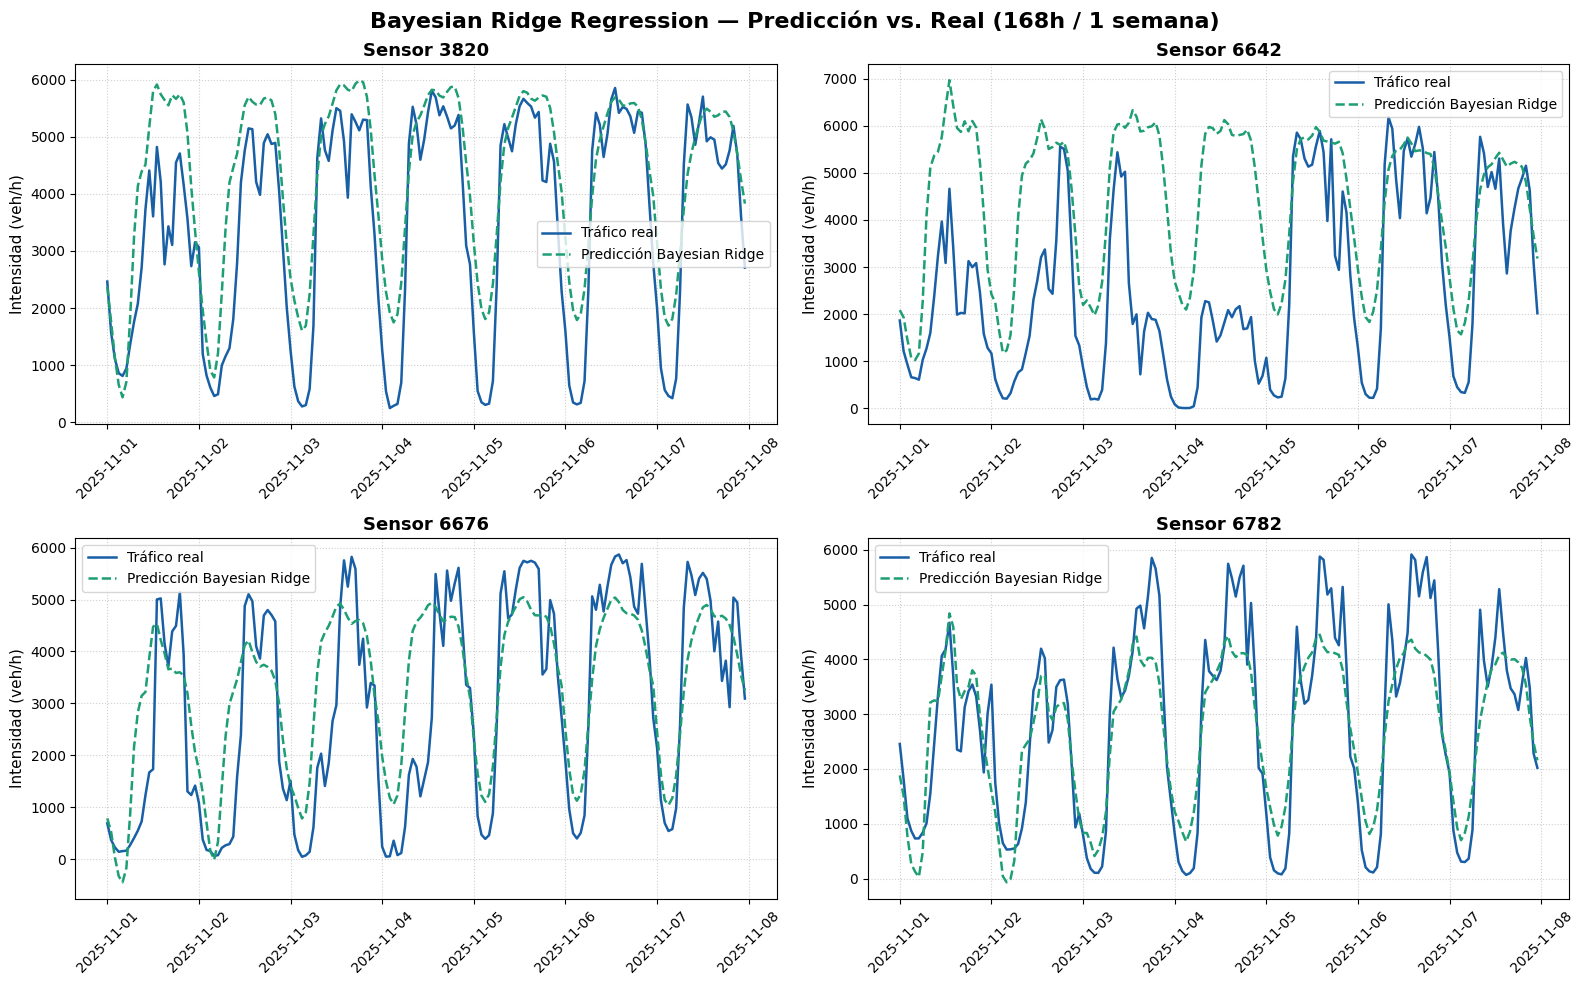

In [10]:
import matplotlib.pyplot as plt

plt.style.use('default')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
fig.suptitle('Bayesian Ridge Regression — Predicción vs. Real (168h / 1 semana)',
             fontsize=16, fontweight='bold', y=0.98)
axes = axes.flatten()

for i, col in enumerate(cols_intensidad):
    ax = axes[i]
    sensor_id = col.split('_')[-1]

    ax.plot(val_df.index[:168], val_df[col].iloc[:168].values,
            label='Tráfico real', color='#185FA5', linewidth=1.8)
    ax.plot(df_pred_168h.index, df_pred_168h[col].values,
            label='Predicción Bayesian Ridge', color='#1D9E75',
            linestyle='--', linewidth=1.8)

    ax.set_title(f'Sensor {sensor_id}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Intensidad (veh/h)', fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=10)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('grafico_bayesian_ridge_168h.png', dpi=300, bbox_inches='tight')
print("✅ Gráfico guardado: 'grafico_bayesian_ridge_168h.png'")
plt.show()

## Paso 7: Evaluación final sobre Test

In [11]:
print("--- EVALUACIÓN FINAL SOBRE TEST (datos no vistos) ---")

# Para el test, el arranque es el final de val_df
ultimo_val = val_df.iloc[-WINDOW_SIZE:]

pred_test_1h   = predecir_iterativo(modelo_bayesian, ultimo_val, test_df,
                                     cols_intensidad, cols_exogenas, WINDOW_SIZE, steps=1)
pred_test_24h  = predecir_iterativo(modelo_bayesian, ultimo_val, test_df,
                                     cols_intensidad, cols_exogenas, WINDOW_SIZE, steps=24)
pred_test_168h = predecir_iterativo(modelo_bayesian, ultimo_val, test_df,
                                     cols_intensidad, cols_exogenas, WINDOW_SIZE, steps=168)

df_pred_test_1h   = pd.DataFrame(pred_test_1h,   index=test_df.index[:1],   columns=cols_intensidad)
df_pred_test_24h  = pd.DataFrame(pred_test_24h,  index=test_df.index[:24],  columns=cols_intensidad)
df_pred_test_168h = pd.DataFrame(pred_test_168h, index=test_df.index[:168], columns=cols_intensidad)

print("\n========================================")
print("   RESULTADOS BAYESIAN RIDGE — TEST FINAL")
print("========================================")
evaluar_predicciones(test_df, df_pred_test_1h,   cols_intensidad, " 1 HORA   (benchmark)")
evaluar_predicciones(test_df, df_pred_test_24h,  cols_intensidad, "24 HORAS  (medio plazo)")
evaluar_predicciones(test_df, df_pred_test_168h, cols_intensidad, "168 HORAS (largo plazo)")

--- EVALUACIÓN FINAL SOBRE TEST (datos no vistos) ---

   RESULTADOS BAYESIAN RIDGE — TEST FINAL

[ HORIZONTE:  1 HORA   (benchmark) ]
  Sensor 3820  →  RMSE:    24.48 veh/h  |  R²:     nan
  Sensor 6642  →  RMSE:    94.49 veh/h  |  R²:     nan
  Sensor 6676  →  RMSE:   141.41 veh/h  |  R²:     nan
  Sensor 6782  →  RMSE:   246.33 veh/h  |  R²:     nan
  ────────────────────────────────────────────────────
  PROMEDIO GLOBAL   →  RMSE:   126.68 veh/h  |  R²:     nan

[ HORIZONTE: 24 HORAS  (medio plazo) ]
  Sensor 3820  →  RMSE:  1696.86 veh/h  |  R²: -0.6933
  Sensor 6642  →  RMSE:  1742.29 veh/h  |  R²: -0.5076
  Sensor 6676  →  RMSE:  1815.21 veh/h  |  R²: -1.2562
  Sensor 6782  →  RMSE:  1343.37 veh/h  |  R²: -0.8146
  ────────────────────────────────────────────────────
  PROMEDIO GLOBAL   →  RMSE:  1649.43 veh/h  |  R²: -0.8179

[ HORIZONTE: 168 HORAS (largo plazo) ]
  Sensor 3820  →  RMSE:   975.41 veh/h  |  R²:  0.6753
  Sensor 6642  →  RMSE:  1126.22 veh/h  |  R²:  0.6506
  Sen

(995.4288221040877, 0.6394214542274681)